In [1]:
import os
import re
import sys
import glob
import time
import intake
import numpy as np
import pandas as pd
import scipy as io
import xarray as xr
import matplotlib.dates as mdates

from mpi4py import MPI
from datetime import date, datetime, timedelta
from matplotlib import pyplot as plt
from dask.distributed import Client
from xarray.coding.times import CFDatetimeCoder

time_coder = CFDatetimeCoder(use_cftime=True)

In [2]:
client = Client()
client

/home/562/cd3007/miniconda3/envs/mhw_env/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36981 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/36981/status,
Dashboard: /proxy/36981/status,Workers: 7
Total threads: 7,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45371,Workers: 0
Dashboard: /proxy/36981/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:35439,Total threads: 1
Dashboard: /proxy/40529/status,Memory: 4.57 GiB
Nanny: tcp://127.0.0.1:37921,


In [3]:
print('Starting ACCESS-OM2 and SOTS net surface heat flux analysis.')
sys.stdout.flush()

catalog = intake.cat.access_nri


#----------------------------------------------------------------------------------------------
# Date of interest 
#----------------------------------------------------------------------------------------------

start_date = np.datetime64("2010-01-01")
end_date = np.datetime64("2023-12-31")

#----------------------------------------------------------------------------------------------
# Variable of interest in ACCESS-OM1-O1
#----------------------------------------------------------------------------------------------

var   =  'net_sfc_heating'

access_model=['01deg_jra55v140_iaf_cycle4','01deg_jra55v140_iaf_cycle4_jra55v150_extension']
deg = '01deg'

#----------------------------------------------------------------------------------------------
# Variable of interest of SOTS
#----------------------------------------------------------------------------------------------

var_SOTS   =  'HEAT_NET'
#----------------------------------------------------------------------------------------------
# Region of interest
#----------------------------------------------------------------------------------------------

region_lat   = np.array([-50,-45])                    # yt_ocean,N
region_lon   = np.array([145,150])                    # xt_ocean,E
region_lon   = region_lon - 360                         # -> [-213, -205]

region = [region_lat, region_lon]

Starting ACCESS-OM2 and SOTS net surface heat flux analysis.


In [6]:
#----------------------------------------------------------------------------------------------
# This section collects all the variable paths for ACCESS-OM2
#----------------------------------------------------------------------------------------------
path_dict = {var: []}

catalogs = []

for model in access_model:
    filtered = catalog[model].search(
        variable=var,
        frequency='1mon',
        realm='ocean',
    )
    catalogs.append(filtered.df)

# Concatenate dataframes from all models
combined_df = pd.concat(catalogs, ignore_index=True)

df = combined_df[
    (combined_df['start_date'] >= '2010-01-01') &
    (combined_df['start_date'] <= '2023-12-31') &
    (combined_df['filename'].str.contains('mean'))
]


file_list = df['path'].tolist()

path_dict[var].extend(file_list)
path_dict[var].sort(key=lambda f: tuple(map(int, re.search(r'ym_(\d{4})_(\d{2})', f).groups())))


print(f'Processing ACCESS {var} data...')
sys.stdout.flush()

start = time.time()

path_list = path_dict[var]

#----------------------------------------------------------------------------------------------
# Collect ACCESS data
#----------------------------------------------------------------------------------------------

ds = xr.open_mfdataset(
    path_list,
    combine='nested',
    concat_dim='time',
    data_vars='minimal',
    decode_timedelta=True
)

# Slice region and time of interest, average it 
heat_flux = ds[var].sel(
    time=slice(start_date, end_date),
    yt_ocean=slice(region[0][0], region[0][1]),
    xt_ocean=slice(region[1][0], region[1][1])
).mean(dim=["yt_ocean", "xt_ocean"])  

ds.close()

dates = heat_flux['time'].values

units = heat_flux.attrs.get("units", "")

heat_flux.attrs['units'] = units

years = np.unique(heat_flux['time.year'].values)

end = time.time()  

print(f'Finished collecting {var} data.')
sys.stdout.flush()

print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()


Processing ACCESS net_sfc_heating data...
Finished collecting net_sfc_heating data.
Execution time: 0.09 minutes


In [4]:
#----------------------------------------------------------------------------------------------
# Read and collect data for SOTS
#----------------------------------------------------------------------------------------------

print(f'Processing SOTS {var} data...')
sys.stdout.flush()

SOTS_dir  = '/g/data/jk72/mxr581/SOTS-project-data/sots/flux'
SOTS_pattern = os.path.join(SOTS_dir, "IMOS_DWM-*_CFMST_20*.nc")

SOTS_paths = glob.glob(SOTS_pattern)

def extract_year(path):
    match = re.search(r'CFMST_(\d{4})', path)
    if match:
        return int(match.group(1))
  
SOTS_sorted = sorted(SOTS_paths, key=extract_year)

start = time.time()

ds = xr.open_mfdataset(
    SOTS_sorted,
    combine='nested',
    concat_dim='TIME',
    data_vars='minimal',
    coords='minimal',
    compat='override'# need this as position of buoy moves around
)[[var_SOTS]]

SOTS_flux = ds[var_SOTS]

ds.close()

SOTS_years = np.unique(SOTS_flux['TIME.year'].values)

end = time.time()  

print(f'Finished collecting {var} data.')
sys.stdout.flush()

print(f"Execution time: {(end - start)/60:.2f} minutes")
sys.stdout.flush()

Processing SOTS net_sfc_heating data...
Finished collecting net_sfc_heating data.
Execution time: 0.62 minutes


/home/562/cd3007/miniconda3/envs/mhw_env/lib/python3.11/site-packages/distributed/client.py:3363: UserWarning: Sending large graph of size 27.86 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


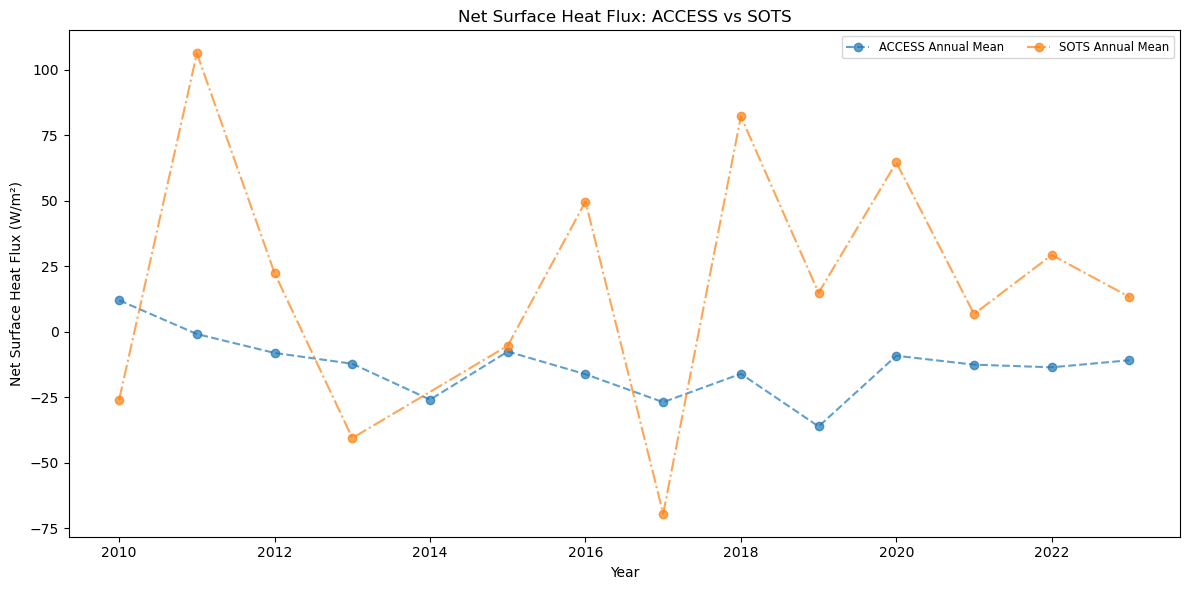

In [7]:
#----------------------------------------------------------------------------------------------
# PLOTS
#----------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# === ACCESS data ===
annual_ACCESS = heat_flux.groupby('time.year').mean(dim='time')
ax.plot(annual_ACCESS['year'], annual_ACCESS.values,
        marker='o', linestyle='--', alpha=0.7, label='ACCESS Annual Mean')

# === SOTS data ===
annual_SOTS = SOTS_flux.groupby('TIME.year').mean(dim='TIME')
ax.plot(annual_SOTS['year'], -1 * annual_SOTS.values,
        marker='o', linestyle='-.', alpha=0.7, label='SOTS Annual Mean')

# Labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Net Surface Heat Flux (W/m²)')
ax.set_title('Net Surface Heat Flux: ACCESS vs SOTS')

ax.legend(ncol=2, fontsize='small', loc='best')
plt.tight_layout()
plt.show()
